In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.ndimage import convolve

In [2]:
W_x = 5
W_y = 5

W = np.array([
                [[+0.0, -0.5, +0.0, -0.5, +0.0],
                  [+0.0, -0.5, +1.0, -0.5, +0.0],
                  [+0.0, -0.5, +1.0, -0.5, +0.0],
                  [+0.0, -0.5, +1.0, -0.5, +0.0],
                  [+0.0, -0.5, +0.0, -0.5, +0.0]],
                [[+0.0, +0.0, -0.5, -0.5, +0.0],
                  [+0.0, -0.5, +0.0, +1.0, -0.5],
                  [-0.5, +0.0, +1.0, +0.0, -0.5],
                  [-0.5, +1.0, +0.0, -0.5, +0.0],
                  [+0.0, -0.5, -0.5, +0.0, +0.0]],
                [[+0.0, +0.0, +0.0, +0.0, +0.0],
                  [-0.5, -0.5, -0.5, -0.5, -0.5],
                  [+0.0, +1.0, +1.0, +1.0, +0.0],
                  [-0.5, -0.5, -0.5, -0.5, -0.5],
                  [+0.0, +0.0, +0.0, +0.0, +0.0]],
                [[+0.0, -0.5, -0.5, +0.0, +0.0],
                  [-0.5, +1.0, +0.0, -0.5, +0.0],
                  [-0.5, +0.0, +1.0, +0.0, -0.5],
                  [+0.0, -0.5, +0.0, +1.0, -0.5],
                  [+0.0, +0.0, -0.5, -0.5, +0.0]]
            ], dtype=float)

In [3]:
cmaps = [   ListedColormap(["black", "#ff0025"]),
            ListedColormap(["black", "#c8ff00"]),
            ListedColormap(["black", "#00ff89"]),
            ListedColormap(["black", "#0017fb"]),
            ]

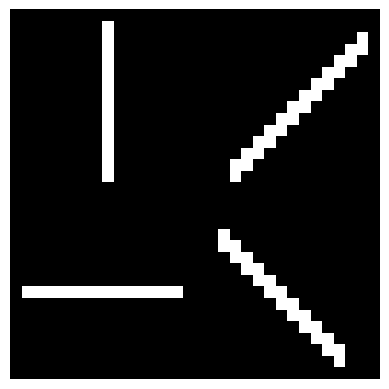

In [8]:
img = Image.open("../images/line_orientations.png").convert('L')
arr = np.array(img).astype(np.float32) / 255.0
plt.imshow(1-arr, cmap="Greys")
plt.axis("off")
plt.savefig("../images/line_orientations_big.png", bbox_inches="tight", pad_inches=0)
plt.show()

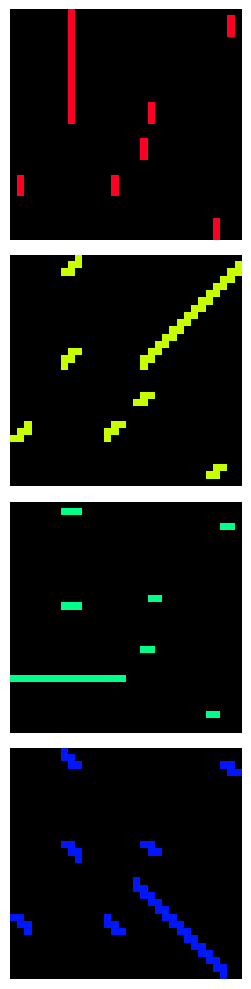

In [7]:
out = []
for W_i in W:
    out.append(np.heaviside(convolve(arr, W_i, mode="constant"), 0))

# Create a vertical stack of subplots: one row per filter/channel
fig, axes = plt.subplots(len(W), 1, figsize=(4, 10))
for i in range(len(W)):
    axes[i].imshow(out[i], cmap=cmaps[i])
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("../images/conv_vis.png", bbox_inches="tight", pad_inches=0)
plt.show()

# | / - \

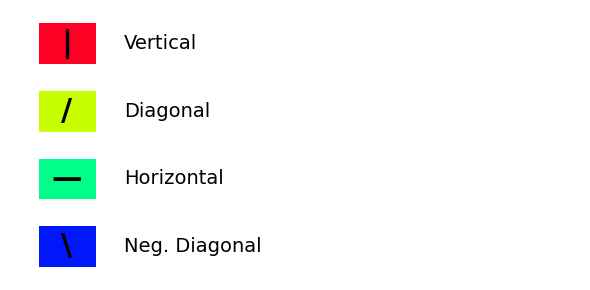

In [13]:
from matplotlib.patches import Rectangle

labels = ["Vertical", "Diagonal", "Horizontal", "Neg. Diagonal"]
symbols = ["|", "/", "—", "\\"]

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

for idx, (cmap, label, sym) in enumerate(zip(cmaps, labels, symbols)):
    y = 3.5 - idx
    color = cmap(1.0)

    # color block
    ax.add_patch(Rectangle((0.5, y - 0.3), 1.0, 0.6, facecolor=color, edgecolor="none"))

    # orientation symbol
    ax.text(1.0, y, sym, ha="center", va="center", fontsize=22, color="black", fontweight="bold")

    # label
    ax.text(2.0, y, label, ha="left", va="center", fontsize=14)

plt.tight_layout()
plt.savefig("../images/conv_vis_legend.png", bbox_inches="tight", pad_inches=0)
plt.show()